# Loading and Pre-processsing the given data

In [1]:
words = open("./names.txt", "r").read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [2]:
len(words)

32033

In [3]:
min_len_word = min(len(w) for w in words)
max_len_word = max(len(w) for w in words)
print(f"min_len_word: {min_len_word}, max_len_word:{max_len_word}")

min_len_word: 2, max_len_word:15


# Algo to make Bigram

In [4]:
# bigram
bigrams_counter = {}
for w in words:
    chs = ['<S>']+list(w)+['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        bigrams_counter[bigram] = bigrams_counter.get(bigram, 0)+1


In [5]:
max(bc for bc in bigrams_counter.values())

6763

In [6]:
bigrams_counter.items()

dict_items([(('<S>', 'e'), 1531), (('e', 'm'), 769), (('m', 'm'), 168), (('m', 'a'), 2590), (('a', '<E>'), 6640), (('<S>', 'o'), 394), (('o', 'l'), 619), (('l', 'i'), 2480), (('i', 'v'), 269), (('v', 'i'), 911), (('i', 'a'), 2445), (('<S>', 'a'), 4410), (('a', 'v'), 834), (('v', 'a'), 642), (('<S>', 'i'), 591), (('i', 's'), 1316), (('s', 'a'), 1201), (('a', 'b'), 541), (('b', 'e'), 655), (('e', 'l'), 3248), (('l', 'l'), 1345), (('l', 'a'), 2623), (('<S>', 's'), 2055), (('s', 'o'), 531), (('o', 'p'), 95), (('p', 'h'), 204), (('h', 'i'), 729), (('<S>', 'c'), 1542), (('c', 'h'), 664), (('h', 'a'), 2244), (('a', 'r'), 3264), (('r', 'l'), 413), (('l', 'o'), 692), (('o', 't'), 118), (('t', 't'), 374), (('t', 'e'), 716), (('e', '<E>'), 3983), (('<S>', 'm'), 2538), (('m', 'i'), 1256), (('a', 'm'), 1634), (('m', 'e'), 818), (('<S>', 'h'), 874), (('r', 'p'), 14), (('p', 'e'), 197), (('e', 'r'), 1958), (('r', '<E>'), 1377), (('e', 'v'), 463), (('v', 'e'), 568), (('l', 'y'), 1588), (('y', 'n'), 18

# Building the bigram count matrix of given names.txt

In [7]:
import torch

In [8]:
# Allocating the bigram count matrix
N = torch.zeros(27,27, dtype=torch.int32)

In [9]:
# set of all chars used in names.txt - sorted
chars = sorted(set(list(''.join(words))))
chars

['a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

In [10]:
char_to_int_map = {c:i+1 for i, c in enumerate(chars)}
char_to_int_map['.']=0 # special for end and start char
int_to_char_map = {i:c for c,i in char_to_int_map.items()}

In [39]:
# Building the bigram count matrix of given names.txt
for w in words:
    chs = ['.']+list(w)+['.']
    for c1, c2 in zip(chs,chs[1:]):
        i_c1 = char_to_int_map[c1]
        i_c2 = char_to_int_map[c2]
        N[i_c1,i_c2]+=1

N_COPY = N

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

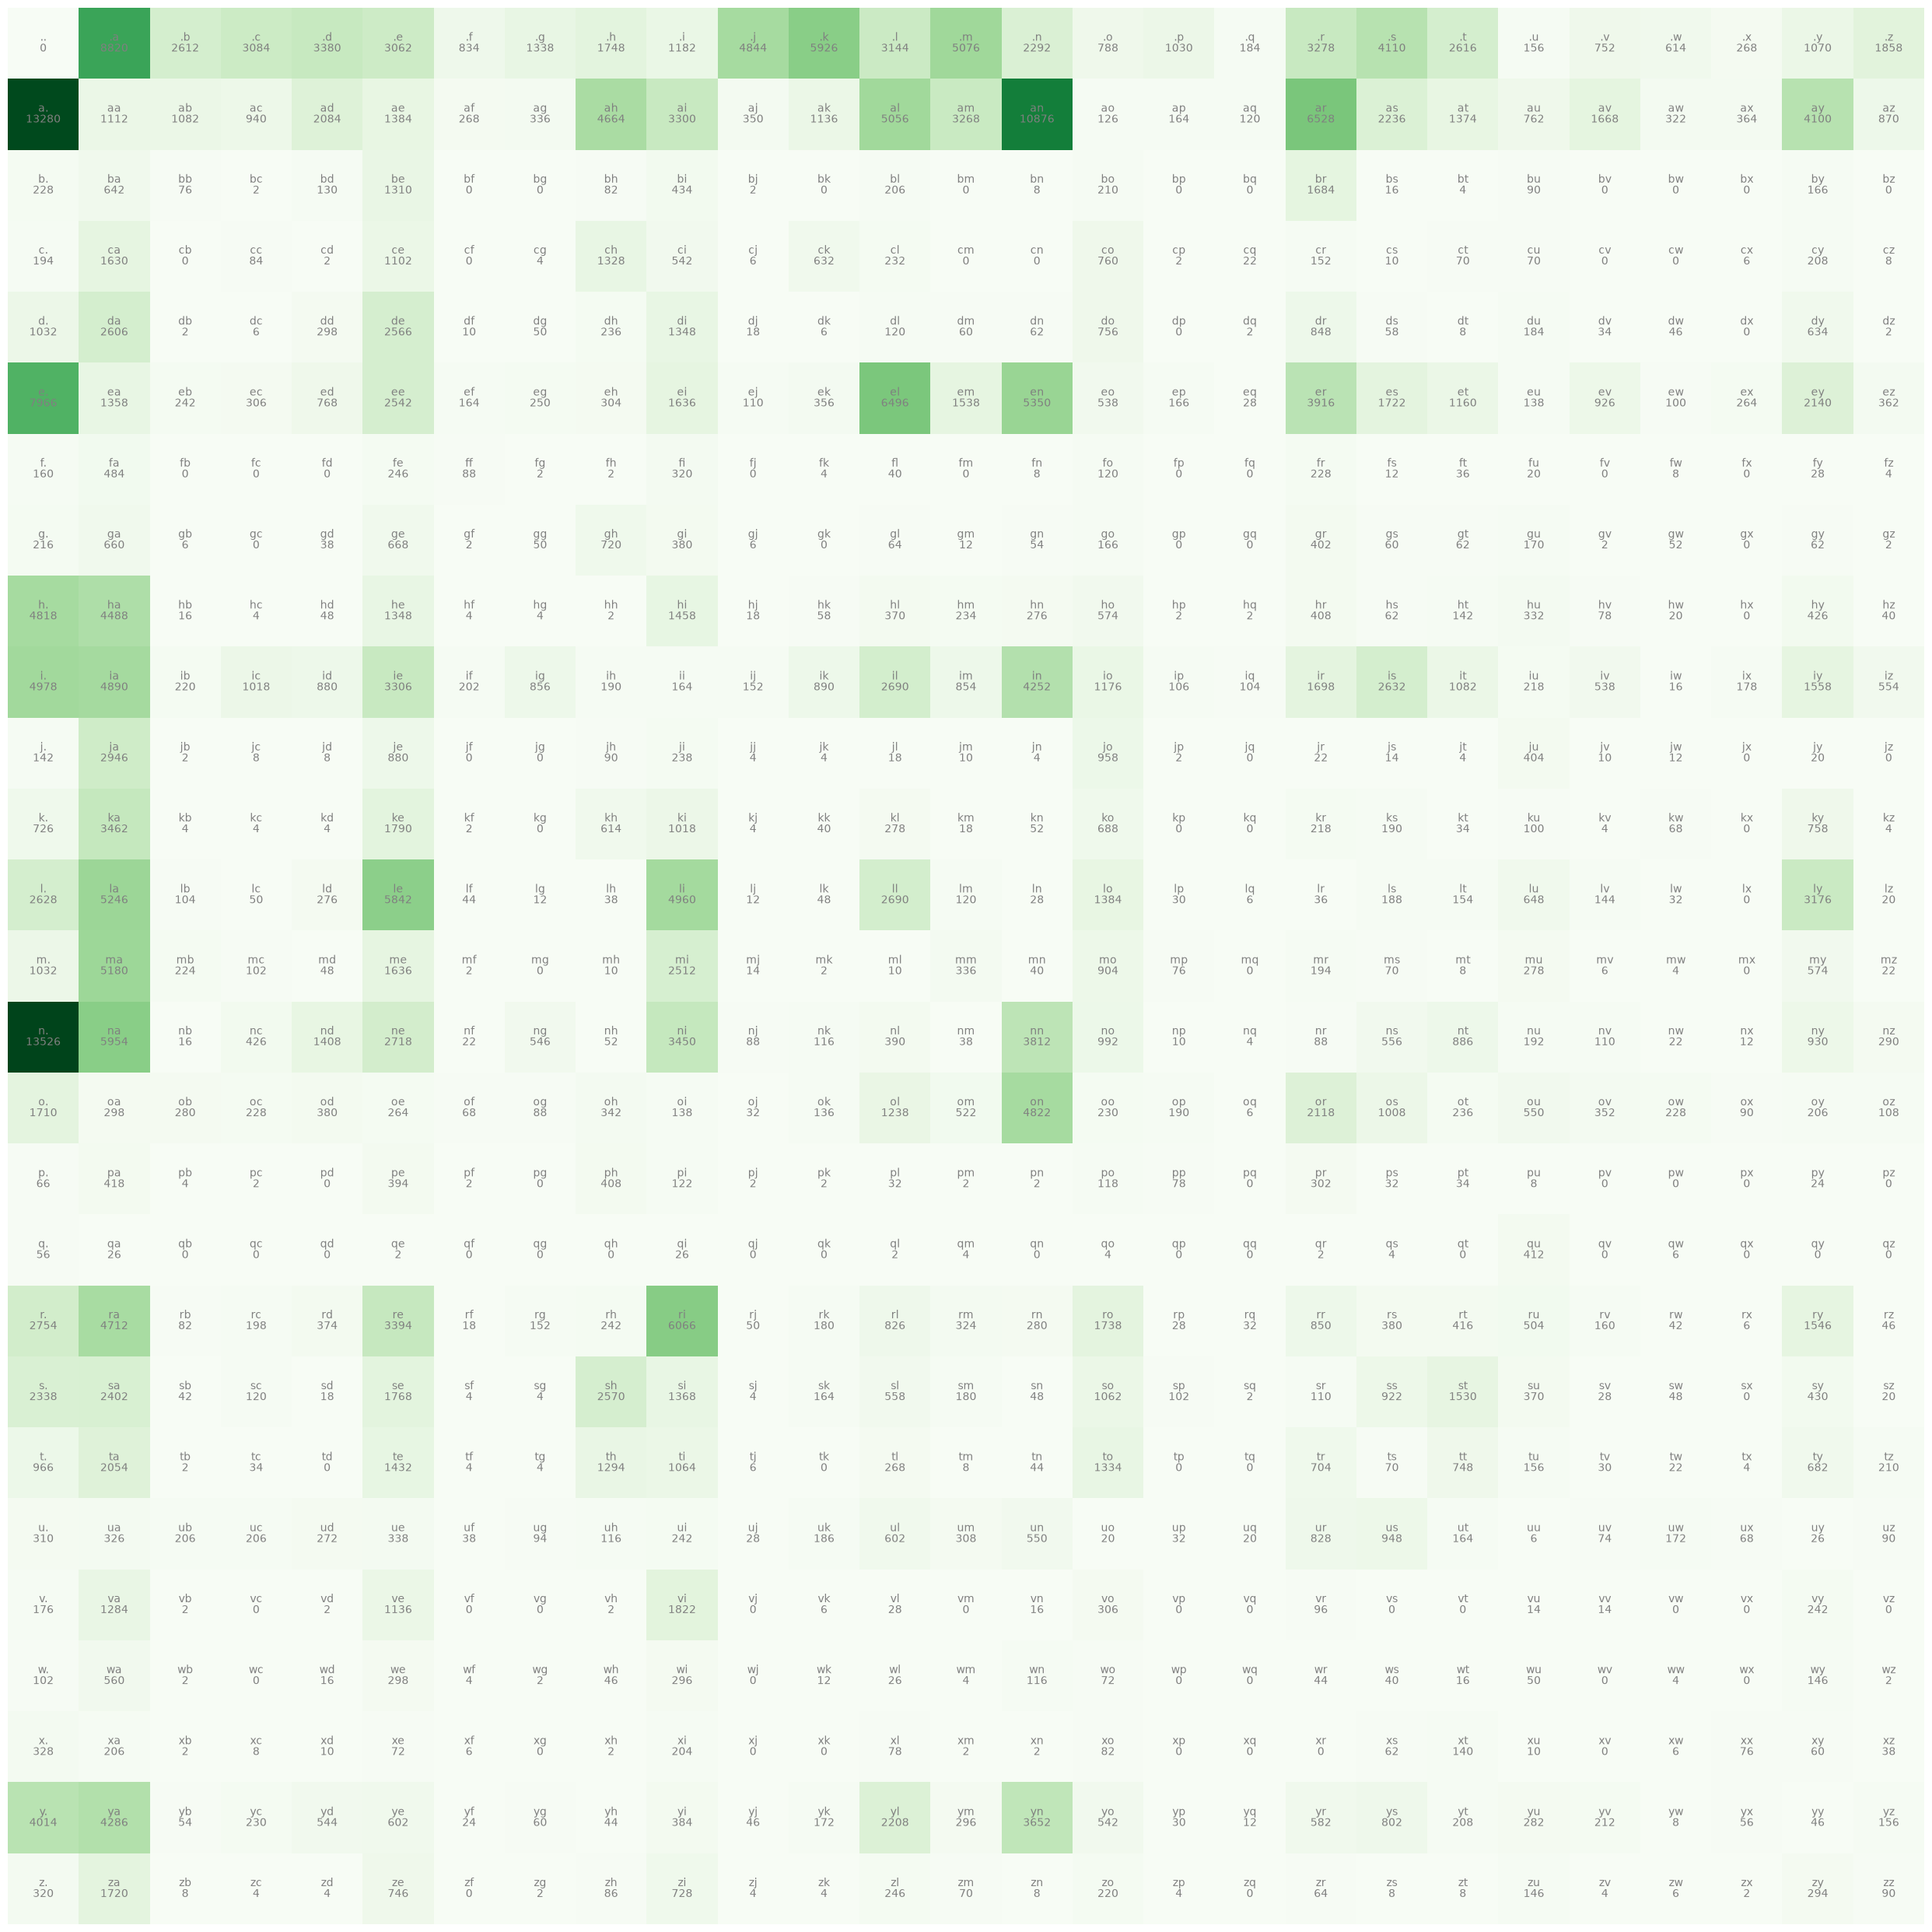

In [40]:
# Illustrating the bigram count matrix of given names.txt
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(32,32))
plt.imshow(N, cmap="Greens")

for i in range(27):
    for j in range(27):
        chstr = int_to_char_map[i]+int_to_char_map[j]
        plt.text(j,i, chstr, ha="center", va="bottom", color="gray")
        plt.text(j,i, N[i,j].item(), ha="center", va="top", color="gray")
plt.axis("off")

In [41]:
N

tensor([[    0,  8820,  2612,  3084,  3380,  3062,   834,  1338,  1748,  1182,
          4844,  5926,  3144,  5076,  2292,   788,  1030,   184,  3278,  4110,
          2616,   156,   752,   614,   268,  1070,  1858],
        [13280,  1112,  1082,   940,  2084,  1384,   268,   336,  4664,  3300,
           350,  1136,  5056,  3268, 10876,   126,   164,   120,  6528,  2236,
          1374,   762,  1668,   322,   364,  4100,   870],
        [  228,   642,    76,     2,   130,  1310,     0,     0,    82,   434,
             2,     0,   206,     0,     8,   210,     0,     0,  1684,    16,
             4,    90,     0,     0,     0,   166,     0],
        [  194,  1630,     0,    84,     2,  1102,     0,     4,  1328,   542,
             6,   632,   232,     0,     0,   760,     2,    22,   152,    10,
            70,    70,     0,     0,     6,   208,     8],
        [ 1032,  2606,     2,     6,   298,  2566,    10,    50,   236,  1348,
            18,     6,   120,    60,    62,   756,   

# Converting counts → probabilities.

In [14]:
p = N[0].float()
p = p/p.sum()

print(p, p.sum())

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290]) tensor(1.)


## Using torch.multinomial

In [15]:
# Random Seed and Generator
SEED = 2
g = torch.Generator().manual_seed(SEED)
for i in range(4):
    test_tensor_rand_value = torch.randint(-1,4,(4,), generator=g)
    print(f"iter {i}:: test_tensor_rand_value: {test_tensor_rand_value}")
    test_tensor_rand_value = test_tensor_rand_value/test_tensor_rand_value.sum()
    print(f"iter {i}:: normalized test_tensor_rand_value: {test_tensor_rand_value}\n")

iter 0:: test_tensor_rand_value: tensor([2, 1, 0, 3])
iter 0:: normalized test_tensor_rand_value: tensor([0.3333, 0.1667, 0.0000, 0.5000])

iter 1:: test_tensor_rand_value: tensor([ 2,  3,  1, -1])
iter 1:: normalized test_tensor_rand_value: tensor([ 0.4000,  0.6000,  0.2000, -0.2000])

iter 2:: test_tensor_rand_value: tensor([-1,  0, -1,  0])
iter 2:: normalized test_tensor_rand_value: tensor([0.5000, -0.0000, 0.5000, -0.0000])

iter 3:: test_tensor_rand_value: tensor([ 3, -1, -1,  2])
iter 3:: normalized test_tensor_rand_value: tensor([ 1.0000, -0.3333, -0.3333,  0.6667])



In [83]:
from torch.types import Tensor

def generate_name_randomly(how_many: int, Data:Tensor):
    g = torch.Generator().manual_seed(214483647)
    for i in range(how_many):
        ix = 0
        out = []
        while True:
            p = Data[ix].float()
            ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
            out.append(int_to_char_map[ix])
            if ix==0:
                break
        print(f"{i+1}. ", "".join(out))

generate_name_randomly(8, N)

1.  nina.
2.  jovyanieryn.
3.  jame.
4.  marillel.
5.  m.
6.  gronann.
7.  y.
8.  pan.


In [53]:
P = N_COPY
P

tensor([[    0,  8820,  2612,  3084,  3380,  3062,   834,  1338,  1748,  1182,
          4844,  5926,  3144,  5076,  2292,   788,  1030,   184,  3278,  4110,
          2616,   156,   752,   614,   268,  1070,  1858],
        [13280,  1112,  1082,   940,  2084,  1384,   268,   336,  4664,  3300,
           350,  1136,  5056,  3268, 10876,   126,   164,   120,  6528,  2236,
          1374,   762,  1668,   322,   364,  4100,   870],
        [  228,   642,    76,     2,   130,  1310,     0,     0,    82,   434,
             2,     0,   206,     0,     8,   210,     0,     0,  1684,    16,
             4,    90,     0,     0,     0,   166,     0],
        [  194,  1630,     0,    84,     2,  1102,     0,     4,  1328,   542,
             6,   632,   232,     0,     0,   760,     2,    22,   152,    10,
            70,    70,     0,     0,     6,   208,     8],
        [ 1032,  2606,     2,     6,   298,  2566,    10,    50,   236,  1348,
            18,     6,   120,    60,    62,   756,   

In [84]:
P = N_COPY.float()
P = P / P.sum(1, keepdim=True)

In [80]:
generate_name_randomly(8, P)

1.  nina.
2.  jovyanieryn.
3.  jame.
4.  marillel.
5.  m.
6.  gronann.
7.  y.
8.  pan.
